Iterative Retrieval with RAG

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph,END

Initializing the LLM

In [2]:
llm = init_chat_model("groq:llama-3.1-8b-instant")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000218F9E28500>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000218FB9FC110>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Loading and Embedding the docs

In [3]:
from langchain_huggingface import HuggingFaceEmbeddings
embedding = HuggingFaceEmbeddings(model="all-MiniLM-L6-v2")
embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

HuggingFaceEmbeddings(model_name='all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

In [5]:
docs = TextLoader("internal_doc.txt",encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks,embedding)
retriever = vectorstore.as_retriever()

State Definition

In [6]:
class State(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0

Node Definitions

In [7]:
def retrieve_docs(state: State) -> State:
    query = state.refined_question or state.question
    docs =retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs":docs})

In [8]:
def generate_answer(state: State) -> State:
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:
    Context:
    {context}
    Question:
    {state.question}
    """
    response = llm.invoke(prompt.strip()).content.strip()
    return state.model_copy(update={"answer":response,"attempts":state.attempts + 1})

In [9]:
def reflect_on_answer(state: State) -> State:
    prompt = f"""Evaluate whether the answer below if factually sufficient and complete.
    Question: {state.question}
    Answer: {state.answer}
    Respond 'YES' if its complete, otherwise 'NO' with feedback.
    """
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified":verified})

In [10]:
def refine_query(state: State) -> State:
    prompt = f"""The answer appears incomplete. Suggest a
    better version of the query that would help retrieve more relevant context.
    Original Question: {state.question}
    Current answer: {state.answer}
    IMPORTANT: RETURN NEW QUERY/QUESTION ONLY DONT RETURN ANY EXPLANATION
    """
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question":new_query})

Building the graph

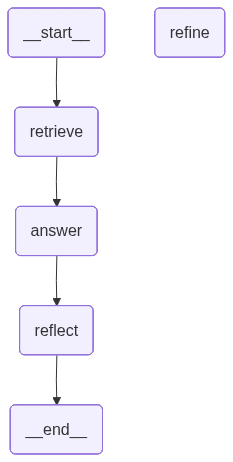

In [11]:
builder = StateGraph(State)

builder.add_node("retrieve",retrieve_docs)
builder.add_node("answer",generate_answer)
builder.add_node("reflect",reflect_on_answer)
builder.add_node("refine",refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve","answer")
builder.add_edge("answer","reflect")
builder.add_conditional_edges(
    "reflect",
    lambda s: END if s.verified or s.attempts >=2 else "refine"
)
builder.add_edge("refine","retrieve")
builder.add_edge("answer",END)
graph = builder.compile()
graph

testing Iterative Retrieval

In [15]:
query = "Which AI model uses the current production embedding model?"
state = State(question=query)
final = graph.invoke(state)
print(f"Query: {query}")
print("Final answer:\n",final['answer'])
print("Verified: ",final['verified'])
print("Attempts: ",final['attempts'])

Query: Which AI model uses the current production embedding model?
Final answer:
 Based on the provided context, the current production embedding model is embed-v5, which is mentioned as the (Current production model) under the "Embedding Models" section. 

However, there is no information directly linking the embed-v5 model to any AI model in the production models section of the "Department: Artificial Intelligence". 

But, as embed-v5 is the current production model, it is likely being used by the Falcon-RAG model which is mentioned as an internal knowledge assistant and uses the embed-v5 model.
Verified:  False
Attempts:  2


In [16]:
final

{'question': 'Which AI model uses the current production embedding model?',
 'refined_question': 'What is the current production embedding model used by the Falcon-RAG AI model and how does it differ from previous versions?',
 'retrieved_docs': [Document(id='5e1b50c3-24fd-4e24-a11a-db8cf1baf139', metadata={'source': 'internal_doc.txt'}, page_content='Falcon-RAG\n- Primary use: Internal knowledge assistant\n- Embedding model: embed-v5\n- Vector database: Pinecone\n- Chunk size: 800 tokens\n- Chunk overlap: 150 tokens\n- Retrieval strategy: Hybrid Search\n- Top-K retrieval: 5\n\nEmbedding Models\n\nembed-v4\nDimension: 768\n\nembed-v5\nDimension: 1536\n(Current production model)\n\n------------------------------------------------------------\n\nDepartment: Infrastructure\n\nCloud Regions\n\nPrimary\n- Mumbai\n- Singapore\n\nSecondary\n- Frankfurt\n- Virginia'),
  Document(id='c8f40f62-f077-49cb-96a1-29c0beab69df', metadata={'source': 'internal_doc.txt'}, page_content='Production Models\n

In [18]:
query = "How many application servers are listed?"
state = State(question=query)
final = graph.invoke(state)
print(f"Query: {query}")
print("Final answer:\n",final['answer'])
print("Verified: ",final['verified'])
print("Attempts: ",final['attempts'])

Query: How many application servers are listed?
Final answer:
 There are 4 application servers listed in the Server Inventory:

- app-node-01
- app-node-02
- app-node-03
- app-node-04
Verified:  True
Attempts:  1


In [19]:
final

{'question': 'How many application servers are listed?',
 'refined_question': '',
 'retrieved_docs': [Document(id='15de6695-86ab-4a21-a8b0-6c526bfac4ae', metadata={'source': 'internal_doc.txt'}, page_content='Server Inventory\n\nApplication Servers\n- app-node-01\n- app-node-02\n- app-node-03\n- app-node-04\n\nDatabase Servers\n- db-primary\n- db-replica\n- db-analytics\n\nCaching\n- redis-cache-01\n- redis-cache-02\n\nStorage\n- object-store-01\n- backup-node-01\n\nMonitoring\n- prometheus-main\n- grafana-dashboard\n\n------------------------------------------------------------\n\nDepartment: Artificial Intelligence\n\nProduction Models'),
  Document(id='c8f40f62-f077-49cb-96a1-29c0beab69df', metadata={'source': 'internal_doc.txt'}, page_content='Production Models\n\nNova-3\n- Primary use: Customer support chatbot\n- Model size: 13B parameters\n- Average response time: 940 ms\n- Context window: 128K tokens\n- Deployment region: Mumbai\n\nAtlas-Vision\n- Primary use: Document OCR\n- Ac